# Imports

In [14]:
import os
import json
import pickle
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model import EvacuationModel
import seaborn as sns
import matplotlib.colors as mcolors    

# Experiment Setup

In [ ]:
# Create experiments directory structure
def create_experiment_structure():
    """Create directory structure for experiments."""
    base_dir = Path("experiments")
    base_dir.mkdir(exist_ok=True)
    return base_dir

def save_experiment_metadata(exp_dir, model_params, agent_params, description=""):
    """Save experiment configuration and metadata."""
    metadata = {
        "experiment_date": datetime.datetime.now().isoformat(),
        "description": description,
        "model_parameters": model_params,
        "agent_parameters": agent_params
    }
    
    with open(exp_dir / "experiment_config.json", "w") as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Saved experiment metadata to {exp_dir / 'experiment_config.json'}")

def save_experiment_data(exp_dir, model_df, agent_df, final_model):
    """Save simulation results and final model state."""
    # Save dataframes as pickle
    with open(exp_dir / "model_data.pkl", "wb") as f:
        pickle.dump(model_df, f)
    
    with open(exp_dir / "agent_data.pkl", "wb") as f:
        pickle.dump(agent_df, f)
    
    
    print(f"Saved simulation data to {exp_dir}")
    print(f"  - model_data.pkl: {model_df.shape}")
    print(f"  - agent_data.pkl: {agent_df.shape}")
    
def load_experiment_results(exp_dir, load_detailed_data=False, parameter_filter=None):
    """
    Load results from a completed experiment with flexible data access.
    
    Args:
        exp_dir: Path to experiment directory
        load_detailed_data: If True, also load model/agent dataframes for each run
        parameter_filter: Dict to filter runs, e.g., {"v0": 2.0} or {"leader_proportion": 0.1}
    
    Returns:
        results_dict: Dictionary containing all experiment data
    """
    exp_dir = Path(exp_dir)
    
    # Load basic experiment info
    with open(exp_dir / "experiment_config.json", "r") as f:
        config = json.load(f)
    
    # Load summary and detailed results
    summary_df = pd.read_csv(exp_dir / "summary_results.csv")
    detailed_df = pd.read_csv(exp_dir / "detailed_results.csv")
    
    # Load raw results if available
    all_results = None
    if (exp_dir / "all_results.json").exists():
        with open(exp_dir / "all_results.json", "r") as f:
            all_results = json.load(f)
    
    print(f"Loaded experiment: {config['description']}")
    print(f"Date: {config['experiment_date']}")
    print(f"Total runs: {len(detailed_df)}")
    
    # Build results dictionary
    results = {
        "config": config,
        "summary_df": summary_df,
        "detailed_df": detailed_df,
        "all_results": all_results,
        "exp_dir": exp_dir
    }
    
    # Identify the varied parameter from the data
    varied_params = []
    for col in detailed_df.columns:
        if col not in ['run', 'total_time', 'evacuated', 'injured', 'evacuation_rate', 
                      'flow_rate', 'simulation_steps', 'computation_time', 
                      'final_agents_remaining', 'timeout']:
            if detailed_df[col].nunique() > 1:
                varied_params.append(col)
    
    if varied_params:
        print(f"Varied parameter(s): {', '.join(varied_params)}")
        results["varied_parameters"] = varied_params
    
    # Apply parameter filter if specified
    if parameter_filter:
        filtered_df = detailed_df.copy()
        for param, value in parameter_filter.items():
            if param in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[param] == value]
                print(f"Filtered to {param} = {value}: {len(filtered_df)} runs")
            else:
                print(f"Warning: Parameter '{param}' not found in data")
        results["filtered_df"] = filtered_df
    
    # Load detailed simulation data if requested
    if load_detailed_data:
        print(f"Loading detailed simulation data...")
        detailed_data = load_simulation_data(exp_dir, parameter_filter)
        results["simulation_data"] = detailed_data
        print(f"Loaded simulation data for {len(detailed_data)} runs")
    
    return results

def load_simulation_data(exp_dir, parameter_filter=None):
    """
    Load model and agent dataframes for specific runs.
    
    Args:
        exp_dir: Path to experiment directory
        parameter_filter: Dict to filter which runs to load, e.g., {"v0": 2.0}
    
    Returns:
        simulation_data: Dict with run info and dataframes
    """
    exp_dir = Path(exp_dir)
    simulation_data = {}
    
    # Get all run directories - updated to include extended agent experiment patterns
    run_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.startswith(('v0_', 'leader_', 'param_', 'fire_'))]
    
    for run_dir in run_dirs:
        # Load run configuration
        run_config_file = run_dir / "run_config.json"
        if not run_config_file.exists():
            continue
            
        with open(run_config_file, "r") as f:
            run_config = json.load(f)
        
        # Apply filter if specified
        if parameter_filter:
            skip_run = False
            for param, value in parameter_filter.items():
                # Check in agent_params first, then model_params, then direct keys
                agent_value = run_config.get("agent_params", {}).get(param)
                model_value = run_config.get("model_params", {}).get(param)
                actual_value = run_config.get(param + "_actual")
                direct_value = run_config.get(param)
                
                run_value = agent_value or model_value or actual_value or direct_value
                
                if run_value != value:
                    skip_run = True
                    break
            
            if skip_run:
                continue
        
        # Load the dataframes
        model_data_file = run_dir / "model_data.pkl"
        agent_data_file = run_dir / "agent_data.pkl"
        
        run_data = {
            "run_config": run_config,
            "run_dir": run_dir,
            "run_name": run_dir.name
        }
        
        if model_data_file.exists():
            with open(model_data_file, "rb") as f:
                run_data["model_df"] = pickle.load(f)
        
        if agent_data_file.exists():
            with open(agent_data_file, "rb") as f:
                run_data["agent_df"] = pickle.load(f)
        
        simulation_data[run_dir.name] = run_data
    
    return simulation_data

# Baseline experiment

In [ ]:
def run_baseline_experiment(v0_values=None, experiment_name="baseline", description="Helbing replication", n_runs=1):
    """
    Run baseline experiment to replicate Helbing's faster-is-slower effect.
    
    Args:
        v0_values: List of desired speeds to test. If None, uses default range.
        experiment_name: Name for this experiment
        description: Description of the experiment
        n_runs: Number of runs per v0 value (for averaging)
    """
    if v0_values is None:
        v0_values = [0.5, 0.8, 1.0, 1.3, 1.5, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]
    
    # Create experiment directory
    base_dir = create_experiment_structure()
    exp_dir = base_dir / f"{experiment_name}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    exp_dir.mkdir(exist_ok=True)
    
    print(f"Starting {experiment_name} experiment")
    print(f"Results will be saved to: {exp_dir}")
    print(f"Testing {len(v0_values)} different v0 values")
    print(f"Running {n_runs} simulation(s) per v0 value")
    
    # Model parameters (Helbing configuration)
    model_params = {
        "n_agents": 50,
        "width": 15.0,
        "height": 15.0,
        "exit_width": 2.0,
        "num_exits": 1,
        "dt": 0.1,
        "integration_method": "euler",
        "agent_type": "simple",
        "enable_fire": False,
        "max_steps": 1000,    # 100 seconds at dt=0.1
        "exit_preset": "center_right"
    }

    base_agent_params = {
        "v0": 1.3,  # Will be overridden per experiment
    }
    
    # Save experiment configuration
    save_experiment_metadata(exp_dir, model_params, base_agent_params, description)
    
    # Results storage
    all_results = []
    
    total_simulations = len(v0_values) * n_runs
    current_sim = 0
    
    for i, v0 in enumerate(v0_values):
        print(f"\n--- Testing v0 = {v0:.1f} m/s ({i+1}/{len(v0_values)}) ---")
        
        v0_results = []  # Store results for this v0 across multiple runs
        
        for run in range(n_runs):
            current_sim += 1
            if n_runs > 1:
                print(f"  Run {run+1}/{n_runs} (Overall: {current_sim}/{total_simulations})")
            
            agent_params = base_agent_params.copy()
            agent_params["v0"] = v0
            
            # Create model with fixed exit
            model = EvacuationModel(
                agent_parameters=agent_params,
                seed=42 + run,  # Different seed for each run
                **{k: v for k, v in model_params.items() if k not in ["max_steps"]}
            )
            
            # Run simulation
            start_time = datetime.datetime.now()
            
            for step in range(model_params["max_steps"]):
                if step % 2000 == 0 and step > 0:
                    remaining = len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
                    elapsed = step * model.dt
                    print(f"    Step {step} ({elapsed:.1f}s): {remaining} agents remaining")
                
                model.step()
                
                if not model.running:
                    print(f"Completed at step {step} ({step * model.dt:.1f}s)")
                    break
            
            end_time = datetime.datetime.now()
            simulation_duration = (end_time - start_time).total_seconds()
            
            # Get results
            model_df = model.datacollector.get_model_vars_dataframe()
            agent_df = model.datacollector.get_agent_vars_dataframe()
            
            # Calculate metrics
            total_time = len(model_df) * model.dt
            evacuated = model.n_agents - len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
            injured = len([a for a in model.agents if getattr(a, "is_pedestrian", False) and getattr(a, "injured", False)])
            
            # Average flow rate (agents per second)
            if total_time > 0:
                flow_rate = evacuated / total_time
            else:
                flow_rate = 0
            
            result = {
                "v0": v0,
                "run": run,
                "total_time": total_time,
                "evacuated": evacuated,
                "injured": injured,
                "evacuation_rate": evacuated / model.n_agents,
                "flow_rate": flow_rate,
                "simulation_steps": len(model_df),
                "computation_time": simulation_duration,
                "final_agents_remaining": len([a for a in model.agents if getattr(a, "is_pedestrian", False)]),
                "timeout": len(model_df) >= model_params["max_steps"]
            }
            
            v0_results.append(result)
            all_results.append(result)
            
            # Save individual run data
            run_dir = exp_dir / f"v0_{v0:.1f}_run_{run}"
            run_dir.mkdir(exist_ok=True)
            save_experiment_data(run_dir, model_df, agent_df, model)
            
            # Save run-specific parameters
            run_config = {
                "model_params": model_params,
                "agent_params": agent_params,
                "v0_actual": v0,
                "run_number": run,
                "seed": 42 + run
            }
            with open(run_dir / "run_config.json", "w") as f:
                json.dump(run_config, f, indent=2)
        
        # Calculate statistics for this v0 across runs
        if n_runs > 1:
            avg_time = np.mean([r["total_time"] for r in v0_results])
            std_time = np.std([r["total_time"] for r in v0_results])
            avg_flow = np.mean([r["flow_rate"] for r in v0_results])
            
            print(f"v0={v0:.1f}: {avg_time:.1f}±{std_time:.1f}s, flow={avg_flow:.2f} agents/s")
        else:
            print(f"v0={v0:.1f}: {v0_results[0]['total_time']:.1f}s, flow={v0_results[0]['flow_rate']:.2f} agents/s")

    # Save summary results
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(exp_dir / "detailed_results.csv", index=False)
    
    # Create aggregated summary (mean across runs)
    if n_runs > 1:
        summary_stats = []
        for v0 in v0_values:
            v0_data = results_df[results_df['v0'] == v0]
            summary_stats.append({
                'v0': v0,
                'total_time_mean': v0_data['total_time'].mean(),
                'total_time_std': v0_data['total_time'].std(),
                'flow_rate_mean': v0_data['flow_rate'].mean(),
                'flow_rate_std': v0_data['flow_rate'].std(),
                'evacuation_rate_mean': v0_data['evacuation_rate'].mean(),
                'injured_mean': v0_data['injured'].mean(),
                'timeout_rate': v0_data['timeout'].mean(),
                'n_runs': len(v0_data)
            })
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    else:
        # For single runs, summary is the same as detailed
        summary_df = results_df.copy()
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    
    # Save raw results
    with open(exp_dir / "all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)
    
    print(f"\nExperiment completed!")
    print(f"All results saved to: {exp_dir}")
    print(f"Summary: {len(v0_values)} v0 values × {n_runs} runs = {len(all_results)} total simulations")

    return summary_df, exp_dir, all_results

## Quick test
- here I ran it twice with 1 replication per condition and with 2 to make sure that the code behaves the same and ensure we get the same results given the same seed.

In [ ]:
# Experiment 1: Quick validation (3 v0 values, single run)
print("Experiment 1: Quick Validation")
v0_quick = [1.0, 2.0, 3.0]
results_quick, exp_dir_quick, _ = run_baseline_experiment(
    v0_values=v0_quick,
    experiment_name="quick_validation",
    description="Quick test with 3 v0 values to validate setup",
    n_runs=2
)

### Example1: How to load general experimnet data

In [4]:
results = load_experiment_results("experiments/quick_validation_20251019_132004")

Loaded experiment: Quick test with 3 v0 values to validate setup
Date: 2025-10-19T13:20:04.767505
Total runs: 6
Varied parameter(s): v0


In [5]:
print("Configuration:")
print(results['config'])

print("\nSummary DataFrame:")
display(results['summary_df'])

print("\nDetailed DataFrame:")
display(results['detailed_df'])

print("\nAll Results:")
display(results['all_results'])

Configuration:
{'experiment_date': '2025-10-19T13:20:04.767505', 'description': 'Quick test with 3 v0 values to validate setup', 'model_parameters': {'n_agents': 200, 'width': 15.0, 'height': 15.0, 'exit_width': 1.0, 'num_exits': 1, 'dt': 0.1, 'integration_method': 'euler', 'agent_type': 'simple', 'enable_fire': False, 'max_steps': 1000, 'exit_preset': 'center_right'}, 'agent_parameters': {'v0': 1.3}}

Summary DataFrame:


,v0,total_time_mean,total_time_std,flow_rate_mean,flow_rate_std,evacuation_rate_mean,injured_mean,timeout_rate,n_runs
0,1.0,100.00,0.000000,1.540000,0.042426,0.77,0.0,1.0,2
1,2.0,84.45,3.889087,2.370779,0.109179,1.00,0.0,0.0,2
2,3.0,65.15,2.474874,3.072055,0.116699,1.00,0.0,0.0,2



Detailed DataFrame:


,v0,run,total_time,evacuated,injured,evacuation_rate,flow_rate,simulation_steps,computation_time,final_agents_remaining,timeout
0,1.0,0,100.0,157,0,0.785,1.570000,1000,79.253922,43,True
1,1.0,1,100.0,151,0,0.755,1.510000,1000,101.554780,49,True
2,2.0,0,87.2,200,0,1.000,2.293578,872,60.115927,0,False
3,2.0,1,81.7,200,0,1.000,2.447980,817,52.876207,0,False
4,3.0,0,63.4,200,0,1.000,3.154574,634,47.079608,0,False
5,3.0,1,66.9,200,0,1.000,2.989537,669,52.625414,0,False



All Results:


[{'v0': 1.0,
  'run': 0,
  'total_time': 100.0,
  'evacuated': 157,
  'injured': 0,
  'evacuation_rate': 0.785,
  'flow_rate': 1.57,
  'simulation_steps': 1000,
  'computation_time': 79.253922,
  'final_agents_remaining': 43,
  'timeout': True},
 {'v0': 1.0,
  'run': 1,
  'total_time': 100.0,
  'evacuated': 151,
  'injured': 0,
  'evacuation_rate': 0.755,
  'flow_rate': 1.51,
  'simulation_steps': 1000,
  'computation_time': 101.55478,
  'final_agents_remaining': 49,
  'timeout': True},
 {'v0': 2.0,
  'run': 0,
  'total_time': 87.2,
  'evacuated': 200,
  'injured': 0,
  'evacuation_rate': 1.0,
  'flow_rate': 2.293577981651376,
  'simulation_steps': 872,
  'computation_time': 60.115927,
  'final_agents_remaining': 0,
  'timeout': False},
 {'v0': 2.0,
  'run': 1,
  'total_time': 81.7,
  'evacuated': 200,
  'injured': 0,
  'evacuation_rate': 1.0,
  'flow_rate': 2.4479804161566707,
  'simulation_steps': 817,
  'computation_time': 52.876207,
  'final_agents_remaining': 0,
  'timeout': False

### Example 2: How to load detailed experimnet data

In [48]:

results_v0_2 = load_experiment_results(
    "experiments/quick_validation_20251019_132004",
    load_detailed_data=True,
    parameter_filter={"v0": 2.0}
)

Loaded experiment: Quick test with 3 v0 values to validate setup
Date: 2025-10-19T13:20:04.767505
Total runs: 6
Varied parameter(s): v0
Filtered to v0 = 2.0: 2 runs
Loading detailed simulation data...
Loaded simulation data for 2 runs


In [49]:
# All of the above shown data is still accessible
# If you use a parameter filter: e.g. parameter_filter={"v0": 2.0} - then you can access a filtered_df that shows data for that specific parameter only
display(results_v0_2['filtered_df'])

# In addition if load_detailed_data is True then you could also access the individual model and agent dataframes for specific visualizations
# Access individual run data
run_0_data = results_v0_2['simulation_data']['v0_2.0_run_0']
run_1_data = results_v0_2['simulation_data']['v0_2.0_run_1']

# Get the model dataframes
model_df_run0 = run_0_data['model_df']
model_df_run1 = run_1_data['model_df']

# Get the agent dataframes  
agent_df_run0 = run_0_data['agent_df']
agent_df_run1 = run_1_data['agent_df']

# Print shapes to see the data
print(f"Run 0 - Model data: {model_df_run0.shape}, Agent data: {agent_df_run0.shape}")
print(f"Run 1 - Model data: {model_df_run1.shape}, Agent data: {agent_df_run1.shape}")

display(model_df_run0.head(5))
display(agent_df_run0.head(5))

,v0,run,total_time,evacuated,injured,evacuation_rate,flow_rate,simulation_steps,computation_time,final_agents_remaining,timeout
2,2.0,0,87.2,200,0,1.0,2.293578,872,60.115927,0,False
3,2.0,1,81.7,200,0,1.0,2.447980,817,52.876207,0,False


Run 0 - Model data: (872, 24), Agent data: (74133, 14)
Run 1 - Model data: (817, 24), Agent data: (67863, 14)


,Agents,Average_Speed,Exit_Flow_Total,Exit0_Flow,Exit1_Flow,Exit2_Flow,Exit_Balance_Entropy,Exit0_Pressure,Exit1_Pressure,Exit2_Pressure,...,Injured_Total,Injured_Fire,Injured_Smoke,Injured_Press,Std_v0_init,Std_vmax,Std_radius,Std_mass,Std_vis,Std_panic0
0,200,0.636531,0,0,0,0,0.0,79.575710,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
1,200,0.998301,0,0,0,0,0.0,52.909412,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
2,200,1.283559,0,0,0,0,0.0,200.783293,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
3,200,1.579458,0,0,0,0,0.0,175.510914,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0
4,199,1.849826,1,1,0,0,-0.0,468.905321,0.0,0.0,...,0,0,0,0,0.0,0.0,0.028819,0.0,0.0,0.0


is_pedestrian  is_leader  injured injury_cause  knows_exit  \
Step AgentID                                                               
1    0                 True      False    False         None       False   
     1                 True      False    False         None       False   
     2                 True      False    False         None       False   
     3                 True      False    False         None       False   
     4                 True      False    False         None       False   

             follow_target_id  smoke_exposure  panic  impatience          x  \
Step AgentID                                                                  
1    0                   None             0.0    0.0         0.0   0.867326   
     1                   None             0.0    0.0         0.0  10.890441   
     2                   None             0.0    0.0         0.0   1.933661   
     3                   None             0.0    0.0         0.0   3.504856   
     4                   None             0.0    0.0         0.0   3.322923   

                     y        vx        vy     Speed  
Step AgentID                                          
1    0        4.375339  0.171753  0.249290  0.302729  
     1        9.984561  0.798444  0.107686  0.805673  
     2        6.389483  2.165178 -0.174230  2.172177  
     3        7.587946 -0.560760  0.129716  0.575568  
     4        9.595591  0.391957 -0.027916  0.392950

In [8]:
print(agent_df_run0.columns)
print(model_df_run0.columns)

Index(['is_pedestrian', 'is_leader', 'injured', 'injury_cause', 'knows_exit',
       'follow_target_id', 'smoke_exposure', 'panic', 'impatience', 'x', 'y',
       'vx', 'vy', 'Speed'],
      dtype='object')
Index(['Agents', 'Average_Speed', 'Exit_Flow_Total', 'Exit0_Flow',
       'Exit1_Flow', 'Exit2_Flow', 'Exit_Balance_Entropy', 'Exit0_Pressure',
       'Exit1_Pressure', 'Exit2_Pressure', 'Followers_Latched',
       'Leaders_Remaining', 'Mean_VisTerm', 'Mean_SmokeExposure',
       'Injured_Total', 'Injured_Fire', 'Injured_Smoke', 'Injured_Press',
       'Std_v0_init', 'Std_vmax', 'Std_radius', 'Std_mass', 'Std_vis',
       'Std_panic0'],
      dtype='object')


## Full SImple Agent experiment

In [9]:
# Full Helbing experiment (default v0 range, single run)
print("Experiment 2: Full Helbing replication with 3 replicates per condition")
v0_helbing_complete = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
results_full, exp_dir_full, _ = run_baseline_experiment(
    v0_values=v0_helbing_complete,
    experiment_name="full_Helbing_replication",
    description="Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition",
    n_runs=3
)

Experiment 2: Full Helbing replication with 3 replicates per condition
Starting full_Helbing_replication experiment
Results will be saved to: experiments\full_Helbing_replication_20251020_131137
Testing 20 different v0 values
Running 3 simulation(s) per v0 value
Saved experiment metadata to experiments\full_Helbing_replication_20251020_131137\experiment_config.json

--- Testing v0 = 0.5 m/s (1/20) ---
  Run 1/3 (Overall: 1/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Saved simulation data to experiments\full_Helbing_replication_20251020_131137\v0_0.5_run_0
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (29998, 14)
  Run 2/3 (Overall: 2/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Saved simulation data to experiments\full_Helbing_replication_20251020_131137\v0_0.5_run_1
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (30023, 14)
  Run 3/3 (Overall: 3/60)


...

Saved simulation data to experiments\full_Helbing_replication_20251020_131137\v0_10.0_run_0
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (44057, 14)
  Run 2/3 (Overall: 59/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Completed at step 18 (1.8s)
Saved simulation data to experiments\full_Helbing_replication_20251020_131137\v0_10.0_run_1
  - model_data.pkl: (19, 24)
  - agent_data.pkl: (885, 14)
  Run 3/3 (Overall: 60/60)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Completed at step 17 (1.7s)
Saved simulation data to experiments\full_Helbing_replication_20251020_131137\v0_10.0_run_2
  - model_data.pkl: (18, 24)
  - agent_data.pkl: (877, 14)
v0=10.0: 34.6±46.3s, flow=1.45 agents/s

Experiment completed!
All results saved to: experiments\full_Helbing_replication_20251020_131137
Summary: 20 v0 values × 3 runs = 60 total simulations


### Plots

In [ ]:
def create_focused_helbing_plots(exp_dir, save_plots=False):
    """
    Create focused Helbing visualizations showing injuries and evacuation success.
    
    Args:
        exp_dir: Path to experiment directory
        save_plots: Whether to save plots to files
    """
    # Load the experiment results
    results = load_experiment_results(exp_dir)
    
    has_std = 'total_time_std' in results['summary_df'].columns
    
    # Set up the plotting style
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'axes.linewidth': 1.5,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'lines.linewidth': 2.5,
        'lines.markersize': 8
    })
    
    # Create figure with 1x2 layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Number of Injuries vs Desired Speed
    if has_std:
        injured_col = 'injured_mean'
        injured_std = results['summary_df'].get('injured_std', None)
        
        if injured_std is not None:
            ax1.errorbar(results['summary_df']['v0'], 
                        results['summary_df'][injured_col],
                        yerr=injured_std,
                        fmt='o-', color='red', linewidth=2.5, markersize=8,
                        capsize=5, capthick=2, label='Number of Injured People')
        else:
            ax1.plot(results['summary_df']['v0'], 
                    results['summary_df'][injured_col],
                    'o-', color='red', linewidth=2.5, markersize=8,
                    label='Number of Injured People')
    else:
        injured_col = 'injured'
        ax1.plot(results['summary_df']['v0'], 
                results['summary_df'][injured_col],
                'o-', color='red', linewidth=2.5, markersize=8,
                label='Number of Injured People')
    
    ax1.set_xlabel('Desired Velocity v₀ (m/s)')
    ax1.set_ylabel('Number of Injured People')
    ax1.set_title('(a) Injuries vs Desired Speed\n(100-second simulation)')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, max(results['summary_df']['v0']) + 0.5)
    ax1.set_ylim(bottom=0)
    
    # Plot 2: Evacuation Rate Only
    if has_std:
        evac_rate = results['summary_df']['evacuation_rate_mean'] * 100
        
        evac_std = results['summary_df'].get('evacuation_rate_std', None)
        if evac_std is not None:
            evac_rate_std = evac_std * 100
            ax2.errorbar(results['summary_df']['v0'], evac_rate,
                        yerr=evac_rate_std,
                        fmt='o-', color='blue', linewidth=2.5, markersize=8,
                        capsize=5, capthick=2, label='Evacuation Rate')
        else:
            ax2.plot(results['summary_df']['v0'], evac_rate,
                    'o-', color='blue', linewidth=2.5, markersize=8,
                    label='Evacuation Rate')
    else:
        evac_rate = results['summary_df']['evacuation_rate'] * 100
        ax2.plot(results['summary_df']['v0'], evac_rate,
                'o-', color='blue', linewidth=2.5, markersize=8,
                label='Evacuation Rate')
    
    ax2.set_xlabel('Desired Velocity v₀ (m/s)')
    ax2.set_ylabel('Evacuation Success Rate (%)')
    ax2.set_title('(b) Evacuation Success vs Desired Speed\n(100-second simulation)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, max(results['summary_df']['v0']) + 0.5)
    ax2.set_ylim(0, 105)
    
    plt.tight_layout()
    
    if save_plots:
        plot_path = Path(exp_dir) / "focused_helbing_plots.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    plt.show()

- in the plot we see that as the desired speed increase past 1.5 m/s less and less people are able to evacuate (faster is slower effect). In the same time more and more people get injured.

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0


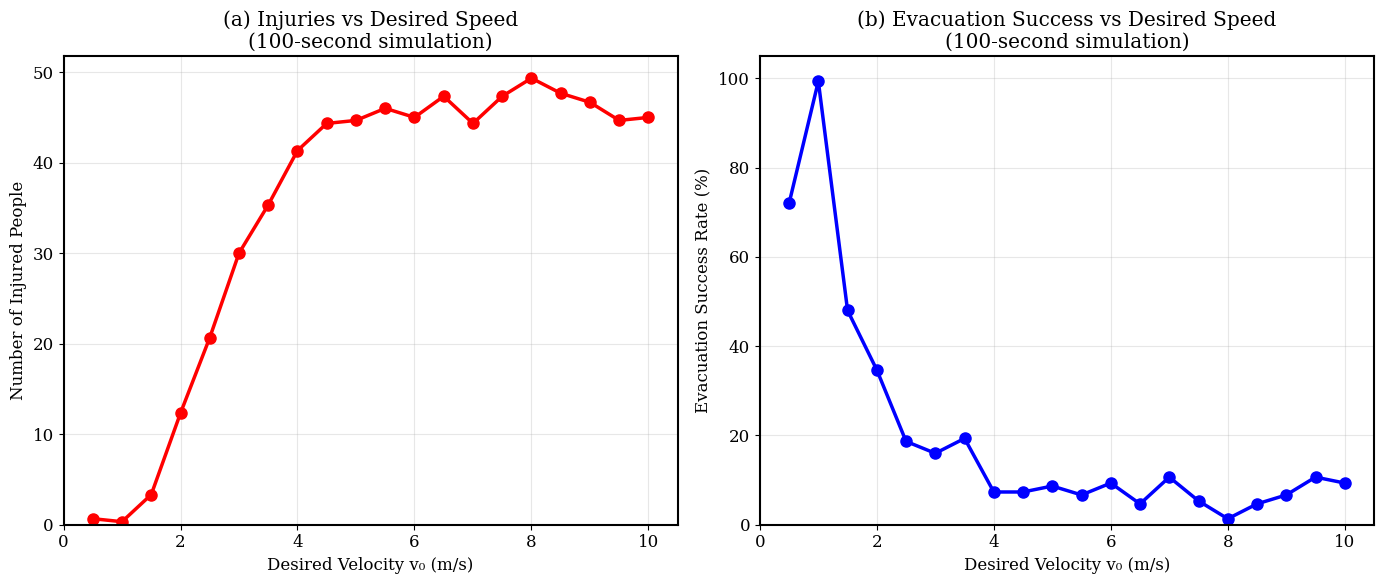

In [14]:
create_focused_helbing_plots("experiments/full_Helbing_replication_20251020_092105", save_plots=True)

In [ ]:
def create_agent_leaving_times_plot(exp_dir, save_plots=False):
    """
    Alternative approach: Use agent position data to determine when agents left.
    """
    results = load_experiment_results(exp_dir)
    v0_values = sorted(results['summary_df']['v0'].unique())
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    all_leaving_times = []
    all_v0_values = []
    
    for v0 in v0_values:
        print(f"Processing v0 = {v0:.1f} m/s...")
        
        v0_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter={"v0": v0}
        )
        
        v0_leaving_times = []
        
        for run_name, run_data in v0_results['simulation_data'].items():
            if 'agent_df' not in run_data:
                continue
                
            agent_df = run_data['agent_df']
            dt = 0.1
            
            # Get unique agent IDs
            agent_ids = agent_df.index.get_level_values('AgentID').unique()
            
            for agent_id in agent_ids:
                try:
                    # Get this agent's data over time
                    agent_data = agent_df.xs(agent_id, level='AgentID')
                    
                    # Agent left when they disappear from the data OR reach exit
                    last_step = agent_data.index.max()
                    leaving_time = last_step * dt
                    
                    # Only include if agent actually evacuated (not just simulation ended)
                    if leaving_time < 100.0:
                        v0_leaving_times.append(leaving_time)
                        
                except Exception as e:
                    continue
        
        all_leaving_times.extend(v0_leaving_times)
        all_v0_values.extend([v0] * len(v0_leaving_times))
    
    # Plot
    all_leaving_times = np.array(all_leaving_times)
    all_v0_values = np.array(all_v0_values)
    
    for v0 in v0_values:
        mask = all_v0_values == v0
        times = all_leaving_times[mask]
        v0_array = np.full_like(times, v0)
        
        jitter = np.random.normal(0, 0.05, size=len(times))
        v0_jittered = v0_array + jitter
        
        color = 'green' if v0 in [0.5, 1.0] else 'red'
        ax.scatter(v0_jittered, times, c=color, marker='+', s=30, alpha=0.7)
    
    ax.set_xlabel('Desired Velocity v₀ (m/s)')
    ax.set_ylabel('Leaving Time T (s)')
    ax.set_title('Individual Agent Leaving Times vs Desired Speed for all 3 runs')
    ax.grid(True, alpha=0.3)
    
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='+', color='green', linestyle='None',
               markersize=10, markeredgewidth=2, label='v₀ = 0.5, 1.0 m/s'),
        Line2D([0], [0], marker='+', color='red', linestyle='None',
               markersize=10, markeredgewidth=2, label='v₀ ≥ 1.5 m/s')
    ]
    ax.legend(handles=legend_elements)
    
    plt.tight_layout()
    if save_plots:
        plot_path = Path(exp_dir) / "agent_leaving_times_plot.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

- we see that as the desired speed increases - agents tend to get injured near the exit resultsing at a bottleneck that prevents other agents from leaving

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Processing v0 = 0.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 0.5: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.0 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 1.0: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5

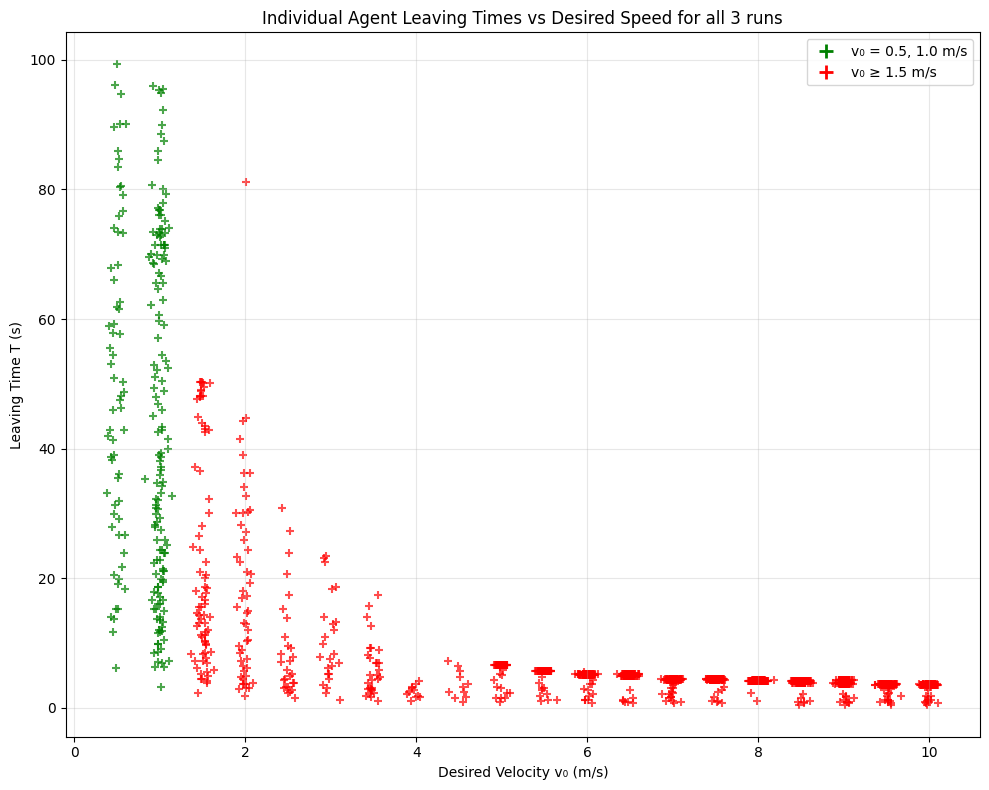

In [47]:
create_agent_leaving_times_plot("experiments/full_Helbing_replication_20251020_092105", save_plots=True)

In [16]:
def create_temporal_evolution_plots(exp_dir, v0_values_to_plot=None, save_plots=False):
    """
    Create plots showing average speed and agent count evolution over time for different v0 values.
    
    Args:
        exp_dir: Path to experiment directory
        v0_values_to_plot: List of v0 values to plot. If None, plots all available values.
        save_plots: Whether to save plots to files
    """
    # Load experiment results
    results = load_experiment_results(exp_dir)
    available_v0s = sorted(results['summary_df']['v0'].unique())
    
    if v0_values_to_plot is None:
        v0_values_to_plot = available_v0s
    else:
        # Filter to only available values
        v0_values_to_plot = [v0 for v0 in v0_values_to_plot if v0 in available_v0s]
    
    print(f"Creating temporal evolution plots for v0 values: {v0_values_to_plot}")
    
    # Set up plotting style
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'axes.linewidth': 1.5,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'lines.linewidth': 2.0
    })
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Color map for different v0 values
    colors = plt.cm.viridis(np.linspace(0, 1, len(v0_values_to_plot)))
    
    for i, v0 in enumerate(v0_values_to_plot):
        print(f"Processing v0 = {v0:.1f} m/s...")
        
        v0_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter={"v0": v0}
        )
        
        if not v0_results['simulation_data']:
            print(f"  No data found for v0={v0}")
            continue
        
        first_run = list(v0_results['simulation_data'].values())[0]
        
        if 'model_df' not in first_run:
            print(f"  No model data for v0={v0}")
            continue
        
        model_df = first_run['model_df']
        
        # Extract time series data
        steps = model_df.index  # Step numbers
        times = steps * 0.1    # Convert to time in seconds
        avg_speeds = model_df['Average_Speed']
        agent_counts = model_df['Agents']
        
        color = colors[i]
        
        # Plot 1: Average Speed over time
        ax1.plot(times, avg_speeds, color=color, linewidth=2.0, 
                label=f'v₀ = {v0:.1f} m/s', alpha=0.8)
        
        # Plot 2: Agent Count over time
        ax2.plot(times, agent_counts, color=color, linewidth=2.0, 
                label=f'v₀ = {v0:.1f} m/s', alpha=0.8)
    
    # Customize Plot 1: Average Speed
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Average Speed (m/s)')
    ax1.set_title('(a) Average Speed Evolution Over Time')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(0, 100)  # 100 second simulation
    
    # Customize Plot 2: Agent Count
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Number of Agents')
    ax2.set_title('(b) Agent Count Evolution Over Time')
    ax2.grid(True, alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.set_xlim(0, 100)  # 100 second simulation
    ax2.set_ylim(0, 50)   # Max 50 agents
    
    plt.tight_layout()
    
    if save_plots:
        plot_path = Path(exp_dir) / "temporal_evolution_plots.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"Saved temporal evolution plots to: {plot_path}")
    
    plt.show()

def create_individual_temporal_plots(exp_dir, v0_values_to_plot=None, save_plots=False):
    """
    Create separate subplots for each v0 value showing speed and agent count evolution.
    """
    # Load experiment results
    results = load_experiment_results(exp_dir)
    available_v0s = sorted(results['summary_df']['v0'].unique())
    
    if v0_values_to_plot is None:
        v0_values_to_plot = available_v0s[:6]
    else:
        v0_values_to_plot = [v0 for v0 in v0_values_to_plot if v0 in available_v0s]
    
    print(f"Creating individual temporal plots for v0 values: {v0_values_to_plot}")
    
    # Set up plotting style
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'serif',
        'axes.linewidth': 1.5,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'lines.linewidth': 2.0
    })
    
    # Create subplots grid
    n_plots = len(v0_values_to_plot)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, v0 in enumerate(v0_values_to_plot):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        print(f"Processing v0 = {v0:.1f} m/s...")
        
        # Load detailed data for this v0
        v0_results = load_experiment_results(
            exp_dir, load_detailed_data=True, parameter_filter={"v0": v0}
        )
        
        if not v0_results['simulation_data']:
            continue
        
        # Get first run data
        first_run = list(v0_results['simulation_data'].values())[0]
        
        if 'model_df' not in first_run:
            continue
        
        model_df = first_run['model_df']
        
        # Extract time series data
        times = model_df.index * 0.1  # Convert to time in seconds
        avg_speeds = model_df['Average_Speed']
        agent_counts = model_df['Agents']
        
        # Plot both speed and agent count on same subplot
        ax_twin = ax.twinx()
        
        # Speed on left axis (blue)
        line1 = ax.plot(times, avg_speeds, 'b-', linewidth=2.0, alpha=0.7, label='Avg Speed')
        ax.set_ylabel('Average Speed (m/s)', color='b')
        ax.tick_params(axis='y', labelcolor='b')
        
        # Agent count on right axis (red)
        line2 = ax_twin.plot(times, agent_counts, 'r-', linewidth=2.0, alpha=0.7, label='Agent Count')
        ax_twin.set_ylabel('Number of Agents', color='r')
        ax_twin.tick_params(axis='y', labelcolor='r')
        
        ax.set_xlabel('Time (s)')
        ax.set_title(f'v₀ = {v0:.1f} m/s')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 100)
        
        # Add legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc='upper right')
    
    # Hide unused subplots
    for i in range(len(v0_values_to_plot), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    
    if save_plots:
        plot_path = Path(exp_dir) / "individual_temporal_plots.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"Saved individual temporal plots to: {plot_path}")
    
    plt.show()

- plots could show that the higher the desired speed the more steep is the initial drop of average speed.

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Creating temporal evolution plots for v0 values: [0.5, 1.0, 1.5, 2.0]
Processing v0 = 0.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 0.5: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.0 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 1.0: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.5 m/s...
Loaded experiment: Fu

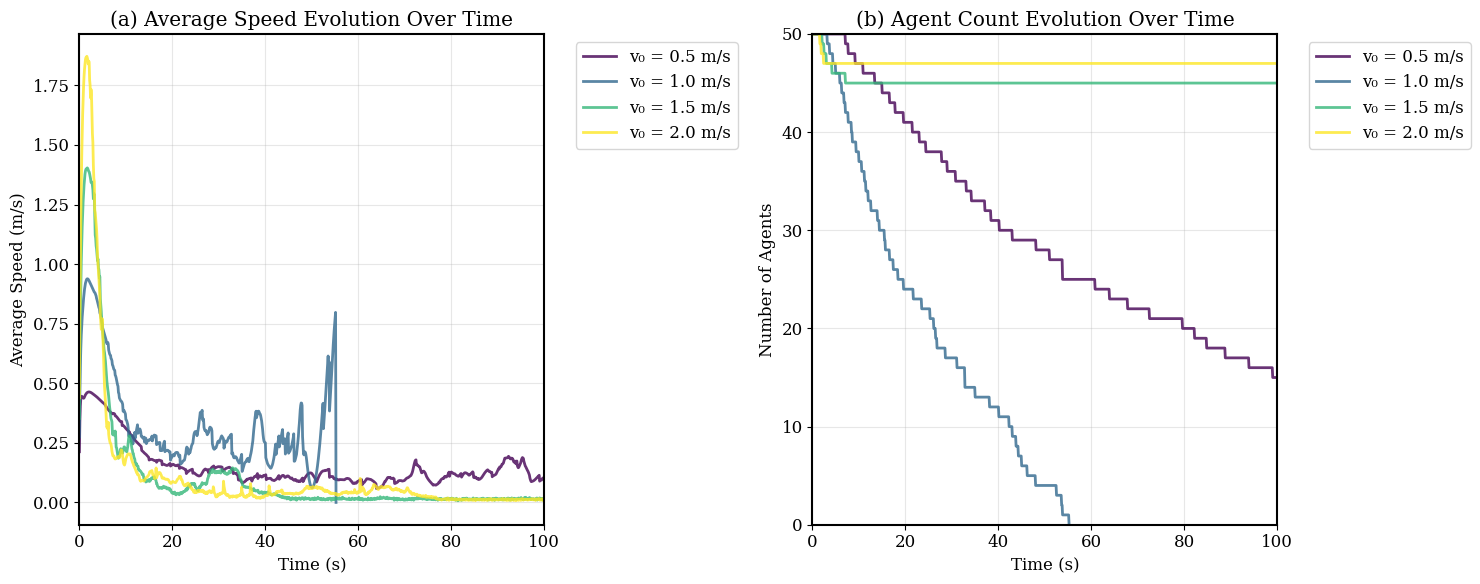

Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Creating individual temporal plots for v0 values: [0.5, 1.0, 1.5, 2.0]
Processing v0 = 0.5 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 0.5: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.0 m/s...
Loaded experiment: Full Helbing replication experiment with desired speeds ranging from 0.5 to 10 m/s with and 3 replicates per condition
Date: 2025-10-20T09:21:05.226111
Total runs: 60
Varied parameter(s): v0
Filtered to v0 = 1.0: 3 runs
Loading detailed simulation data...
Loaded simulation data for 3 runs
Processing v0 = 1.5 m/s...
Loaded experiment: F

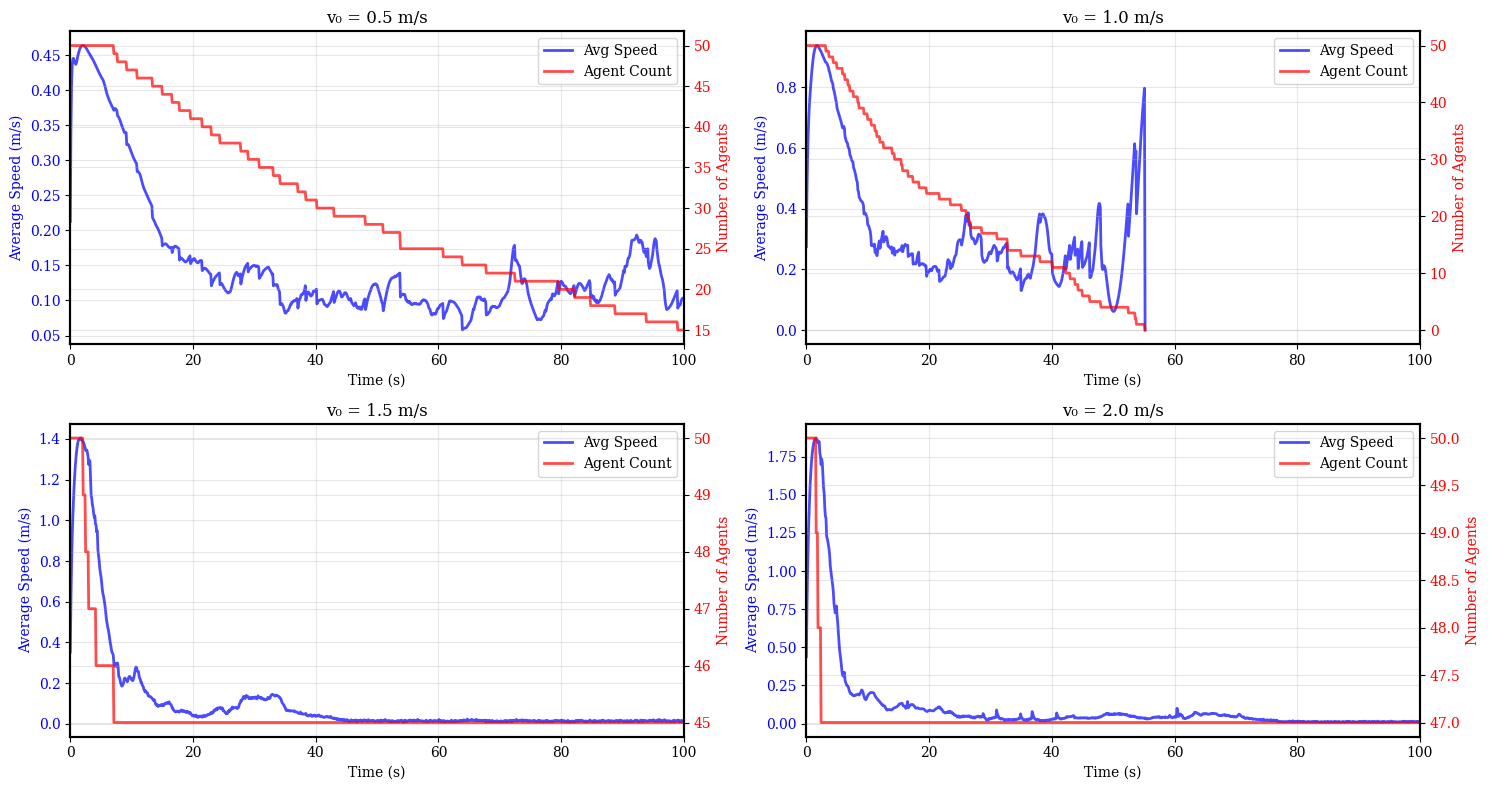

In [17]:
create_temporal_evolution_plots(
    "experiments/full_Helbing_replication_20251020_092105", 
    v0_values_to_plot=[0.5, 1.0, 1.5, 2.0],
    save_plots=False
)
create_individual_temporal_plots(
    "experiments/full_Helbing_replication_20251020_092105",
    v0_values_to_plot=[0.5, 1.0, 1.5, 2.0],
    save_plots=False
)

- I recommend doing some statistical anlysis to show that the average speed you can maintain at lower desired speed is higher then the average speed at higher desired speed

# Extended Agent experiments

In [ ]:
def run_extended_agent_experiment(
    fire_conditions=[False, True],
    exit_presets=["center_right", "two_exits", "three_exits"], 
    leader_proportions=[0, 0.02, 0.06, 0.10, 0.20],
    experiment_name="extended_agents",
    description="Extended agent experiment with fire, exits, and leadership",
    n_runs=5
):
    """
    Run comprehensive extended agent experiment testing fire, exits, and leadership effects.
    
    Args:
        fire_conditions: List of fire enabled/disabled [False, True]
        exit_presets: List of exit configurations
        leader_proportions: List of leader proportions (0-1)
        experiment_name: Name for this experiment
        description: Description of the experiment
        n_runs: Number of runs per condition (for averaging)
    """
    
    # Create experiment directory
    base_dir = create_experiment_structure()
    exp_dir = base_dir / f"{experiment_name}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    exp_dir.mkdir(exist_ok=True)
    
    # Calculate total number of conditions and runs
    total_conditions = len(fire_conditions) * len(exit_presets) * len(leader_proportions)
    total_simulations = total_conditions * n_runs
    
    print(f"Starting {experiment_name} experiment")
    print(f"Results will be saved to: {exp_dir}")
    print(f"Design: {len(fire_conditions)} fire × {len(exit_presets)} exits × {len(leader_proportions)} leadership = {total_conditions} conditions")
    print(f"Running {n_runs} replicates per condition = {total_simulations} total simulations")
    
    # Base model parameters
    base_model_params = {
        "n_agents": 50,
        "width": 15.0,
        "height": 15.0,
        "exit_width": 2.0,
        "dt": 0.1,
        "integration_method": "euler",
        "agent_type": "extended",  # Use extended agents
        "max_steps": 1000,  # 100 seconds at dt=0.1
    }

    # Base agent parameters (we don't vary speed so not used)
    base_agent_params = {}
    
    # Save experiment configuration
    exp_config = {
        "fire_conditions": fire_conditions,
        "exit_presets": exit_presets, 
        "leader_proportions": leader_proportions,
        "n_runs": n_runs,
        "base_model_params": base_model_params,
        "base_agent_params": base_agent_params
    }
    
    save_experiment_metadata(exp_dir, base_model_params, base_agent_params, description)
    
    # Save additional experiment design info
    with open(exp_dir / "experiment_design.json", "w") as f:
        json.dump(exp_config, f, indent=2)
    
    # Results storage
    all_results = []
    current_sim = 0
    
    # Main experimental loop
    for fire_enabled in fire_conditions:
        for exit_preset in exit_presets:
            for leader_prop in leader_proportions:
                
                # Calculate number of leaders (round to nearest integer)
                num_leaders = int(round(leader_prop * base_model_params["n_agents"]))
                
                print(f"\n=== Condition {len(all_results)//n_runs + 1}/{total_conditions} ===")
                print(f"Fire: {fire_enabled}, Exits: {exit_preset}, Leaders: {num_leaders} ({leader_prop:.1%})")
                
                condition_results = []
                
                for run in range(n_runs):
                    current_sim += 1
                    print(f"  Run {run+1}/{n_runs} (Overall: {current_sim}/{total_simulations})")
                    
                    # Build model parameters for this condition
                    model_params = base_model_params.copy()
                    model_params.update({
                        "enable_fire": fire_enabled,
                        "exit_preset": exit_preset,
                        "num_leaders": num_leaders,
                        "num_exits": {"center_right": 1, "two_exits": 2, "three_exits": 3}[exit_preset]
                    })
                    
                    # Create model
                    model = EvacuationModel(
                        agent_parameters=base_agent_params,
                        seed=42 + run,  # Unique seed for each simulation
                        **{k: v for k, v in model_params.items() if k not in ["max_steps"]}
                    )
                    
                    # Run simulation
                    start_time = datetime.datetime.now()
                    
                    for step in range(model_params["max_steps"]):
                        # Progress updates every 50 seconds of simulation time
                        if step % 500 == 0 and step > 0:
                            remaining = len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
                            injured = len([a for a in model.agents if getattr(a, "is_pedestrian", False) and getattr(a, "injured", False)])
                            elapsed = step * model.dt
                            print(f"    Step {step} ({elapsed:.1f}s): {remaining} agents, {injured} injured")
                        
                        model.step()
                        
                        if not model.running:
                            print(f"    Completed at step {step} ({step * model.dt:.1f}s)")
                            break
                    
                    end_time = datetime.datetime.now()
                    simulation_duration = (end_time - start_time).total_seconds()
                    
                    # Get results
                    model_df = model.datacollector.get_model_vars_dataframe()
                    agent_df = model.datacollector.get_agent_vars_dataframe()
                    
                    # Calculate comprehensive metrics
                    total_time = len(model_df) * model.dt
                    remaining_agents = len([a for a in model.agents if getattr(a, "is_pedestrian", False)])
                    evacuated = model.n_agents - remaining_agents
                    injured_agents = [a for a in model.agents if getattr(a, "is_pedestrian", False) and getattr(a, "injured", False)]
                    injured = len(injured_agents)
                    
                    # Injury breakdown
                    injured_fire = len([a for a in injured_agents if getattr(a, "injury_cause", None) == "fire"])
                    injured_smoke = len([a for a in injured_agents if getattr(a, "injury_cause", None) == "smoke"])
                    injured_pressure = len([a for a in injured_agents if getattr(a, "injury_cause", None) == "pressure"])
                    
                    # Leadership metrics
                    leaders_remaining = len([a for a in model.agents if getattr(a, "is_pedestrian", False) and getattr(a, "is_leader", False)])
                    leaders_evacuated = num_leaders - leaders_remaining
                    
                    # Exit usage
                    exit_usage = model.exit_counts.copy()
                    
                    # Flow rates
                    if total_time > 0:
                        overall_flow_rate = evacuated / total_time
                        leader_flow_rate = leaders_evacuated / total_time if num_leaders > 0 else 0
                    else:
                        overall_flow_rate = 0
                        leader_flow_rate = 0
                    
                    # Store results
                    result = {
                        # Experimental conditions
                        "fire_enabled": fire_enabled,
                        "exit_preset": exit_preset,
                        "num_exits": model_params["num_exits"],
                        "leader_proportion": leader_prop,
                        "num_leaders": num_leaders,
                        "run": run,
                        "seed": 1000 + current_sim,
                        
                        # Time and completion metrics
                        "total_time": total_time,
                        "simulation_steps": len(model_df),
                        "computation_time": simulation_duration,
                        "timeout": len(model_df) >= model_params["max_steps"],
                        
                        # Evacuation metrics
                        "evacuated": evacuated,
                        "evacuation_rate": evacuated / model.n_agents,
                        "remaining_agents": remaining_agents,
                        "overall_flow_rate": overall_flow_rate,
                        
                        # Leadership metrics
                        "leaders_evacuated": leaders_evacuated,
                        "leaders_remaining": leaders_remaining,
                        "leader_evacuation_rate": leaders_evacuated / num_leaders if num_leaders > 0 else 1.0,
                        "leader_flow_rate": leader_flow_rate,
                        
                        # Injury metrics
                        "injured_total": injured,
                        "injured_rate": injured / model.n_agents,
                        "injured_fire": injured_fire,
                        "injured_smoke": injured_smoke,
                        "injured_pressure": injured_pressure,
                        
                        # Exit usage metrics
                        "exit0_usage": exit_usage[0] if len(exit_usage) > 0 else 0,
                        "exit1_usage": exit_usage[1] if len(exit_usage) > 1 else 0,
                        "exit2_usage": exit_usage[2] if len(exit_usage) > 2 else 0,
                        "exit_balance": np.std(exit_usage) if len(exit_usage) > 1 else 0,
                    }
                    
                    condition_results.append(result)
                    all_results.append(result)
                    
                    # Save individual run data with appropriate parameters
                    run_dir = exp_dir / f"fire_{fire_enabled}_exits_{exit_preset}_leaders_{leader_prop:.2f}_run_{run}"
                    run_dir.mkdir(exist_ok=True)
                    save_experiment_data(run_dir, model_df, agent_df, model)
                    
                    # Save run-specific parameters
                    run_config = {
                        "model_params": model_params,
                        "agent_params": base_agent_params,
                        "fire_enabled": fire_enabled,
                        "exit_preset": exit_preset,
                        "leader_proportion": leader_prop,
                        "num_leaders": num_leaders,
                        "run_number": run,
                        "seed": 42 + run
                    }
                    with open(run_dir / "run_config.json", "w") as f:
                        json.dump(run_config, f, indent=2)
                
                # Print condition summary
                if n_runs > 1:
                    avg_time = np.mean([r["total_time"] for r in condition_results])
                    avg_evac_rate = np.mean([r["evacuation_rate"] for r in condition_results])
                    avg_injured = np.mean([r["injured_total"] for r in condition_results])
                    
                    print(f"  Condition summary: {avg_time:.1f}s avg time, {avg_evac_rate:.1%} evacuated, {avg_injured:.1f} avg injured")

    # Save comprehensive results
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(exp_dir / "detailed_results.csv", index=False)
    
    # Create aggregated summary (mean across runs for each condition)
    if n_runs > 1:
        summary_stats = []
        
        # Group by experimental conditions
        for fire_enabled in fire_conditions:
            for exit_preset in exit_presets:
                for leader_prop in leader_proportions:
                    condition_data = results_df[
                        (results_df['fire_enabled'] == fire_enabled) & 
                        (results_df['exit_preset'] == exit_preset) & 
                        (results_df['leader_proportion'] == leader_prop)
                    ]
                    
                    if len(condition_data) > 0:
                        summary_stats.append({
                            # Conditions
                            'fire_enabled': fire_enabled,
                            'exit_preset': exit_preset,
                            'num_exits': condition_data['num_exits'].iloc[0],
                            'leader_proportion': leader_prop,
                            'num_leaders': condition_data['num_leaders'].iloc[0],
                            
                            # Aggregated metrics
                            'total_time_mean': condition_data['total_time'].mean(),
                            'total_time_std': condition_data['total_time'].std(),
                            'evacuation_rate_mean': condition_data['evacuation_rate'].mean(),
                            'evacuation_rate_std': condition_data['evacuation_rate'].std(),
                            'injured_total_mean': condition_data['injured_total'].mean(),
                            'injured_total_std': condition_data['injured_total'].std(),
                            'injured_rate_mean': condition_data['injured_rate'].mean(),
                            'leader_evacuation_rate_mean': condition_data['leader_evacuation_rate'].mean(),
                            'overall_flow_rate_mean': condition_data['overall_flow_rate'].mean(),
                            'overall_flow_rate_std': condition_data['overall_flow_rate'].std(),
                            'timeout_rate': condition_data['timeout'].mean(),
                            'exit_balance_mean': condition_data['exit_balance'].mean(),
                            'n_runs': len(condition_data)
                        })
        
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    else:
        # For single runs, summary is the same as detailed
        summary_df = results_df.copy()
        summary_df.to_csv(exp_dir / "summary_results.csv", index=False)
    
    # Save raw results
    with open(exp_dir / "all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)
    
    print(f"\nExperiment completed!")
    print(f"All results saved to: {exp_dir}")

    return summary_df, exp_dir, all_results

In [28]:
# Run the full experiment
print("Extended Agent Experiment: Fire × Exits × Leadership")
results_extended, exp_dir_extended, all_data = run_extended_agent_experiment(
    fire_conditions=[False, True],
    exit_presets=["center_right", "two_exits", "three_exits"], 
    leader_proportions=[0, 0.02, 0.06, 0.10, 0.20],
    experiment_name="extended_agents_full",
    description="Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics",
    n_runs=10
)

Extended Agent Experiment: Fire × Exits × Leadership
Starting extended_agents_full experiment
Results will be saved to: experiments\extended_agents_full_20251020_143838
Design: 2 fire × 3 exits × 5 leadership = 30 conditions
Running 10 replicates per condition = 300 total simulations
Saved experiment metadata to experiments\extended_agents_full_20251020_143838\experiment_config.json

=== Condition 1/30 ===
Fire: False, Exits: center_right, Leaders: 0 (0.0%)
  Run 1/10 (Overall: 1/300)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


    Step 500 (50.0s): 9 agents, 1 injured
Saved simulation data to experiments\extended_agents_full_20251020_143838\fire_False_exits_center_right_leaders_0.00_run_0
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (13030, 14)
  Run 2/10 (Overall: 2/300)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


    Step 500 (50.0s): 10 agents, 0 injured
Saved simulation data to experiments\extended_agents_full_20251020_143838\fire_False_exits_center_right_leaders_0.00_run_1
  - model_data.pkl: (1000, 24)
  - agent_data.pkl: (17475, 14)
  Run 3/10 (Overall: 3/300)


...

    Step 500 (50.0s): 5 agents, 3 injured
    Completed at step 755 (75.5s)
Saved simulation data to experiments\extended_agents_full_20251020_143838\fire_True_exits_three_exits_leaders_0.20_run_7
  - model_data.pkl: (756, 24)
  - agent_data.pkl: (9167, 14)
  Run 9/10 (Overall: 299/300)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


    Completed at step 379 (37.9s)
Saved simulation data to experiments\extended_agents_full_20251020_143838\fire_True_exits_three_exits_leaders_0.20_run_8
  - model_data.pkl: (380, 24)
  - agent_data.pkl: (6243, 14)
  Run 10/10 (Overall: 300/300)


c:\Users\wk218\repos\dmas_project\.venv\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


    Completed at step 299 (29.9s)
Saved simulation data to experiments\extended_agents_full_20251020_143838\fire_True_exits_three_exits_leaders_0.20_run_9
  - model_data.pkl: (300, 24)
  - agent_data.pkl: (5310, 14)
  Condition summary: 53.1s avg time, 95.4% evacuated, 2.3 avg injured

Experiment completed!
All results saved to: experiments\extended_agents_full_20251020_143838


## Plots

In [30]:
# Load the experiment results
exp_dir = Path("experiments/extended_agents_full_20251020_143838")
detailed_df = pd.read_csv(exp_dir / "detailed_results.csv")

print(f"Loaded {len(detailed_df)} simulation results")
print(f"Leader proportions tested: {sorted(detailed_df['leader_proportion'].unique())}")
print(f"Fire conditions: {detailed_df['fire_enabled'].unique()}")
print(f"Exit presets: {detailed_df['exit_preset'].unique()}")

Loaded 300 simulation results
Leader proportions tested: [np.float64(0.0), np.float64(0.02), np.float64(0.06), np.float64(0.1), np.float64(0.2)]
Fire conditions: [False  True]
Exit presets: ['center_right' 'two_exits' 'three_exits']


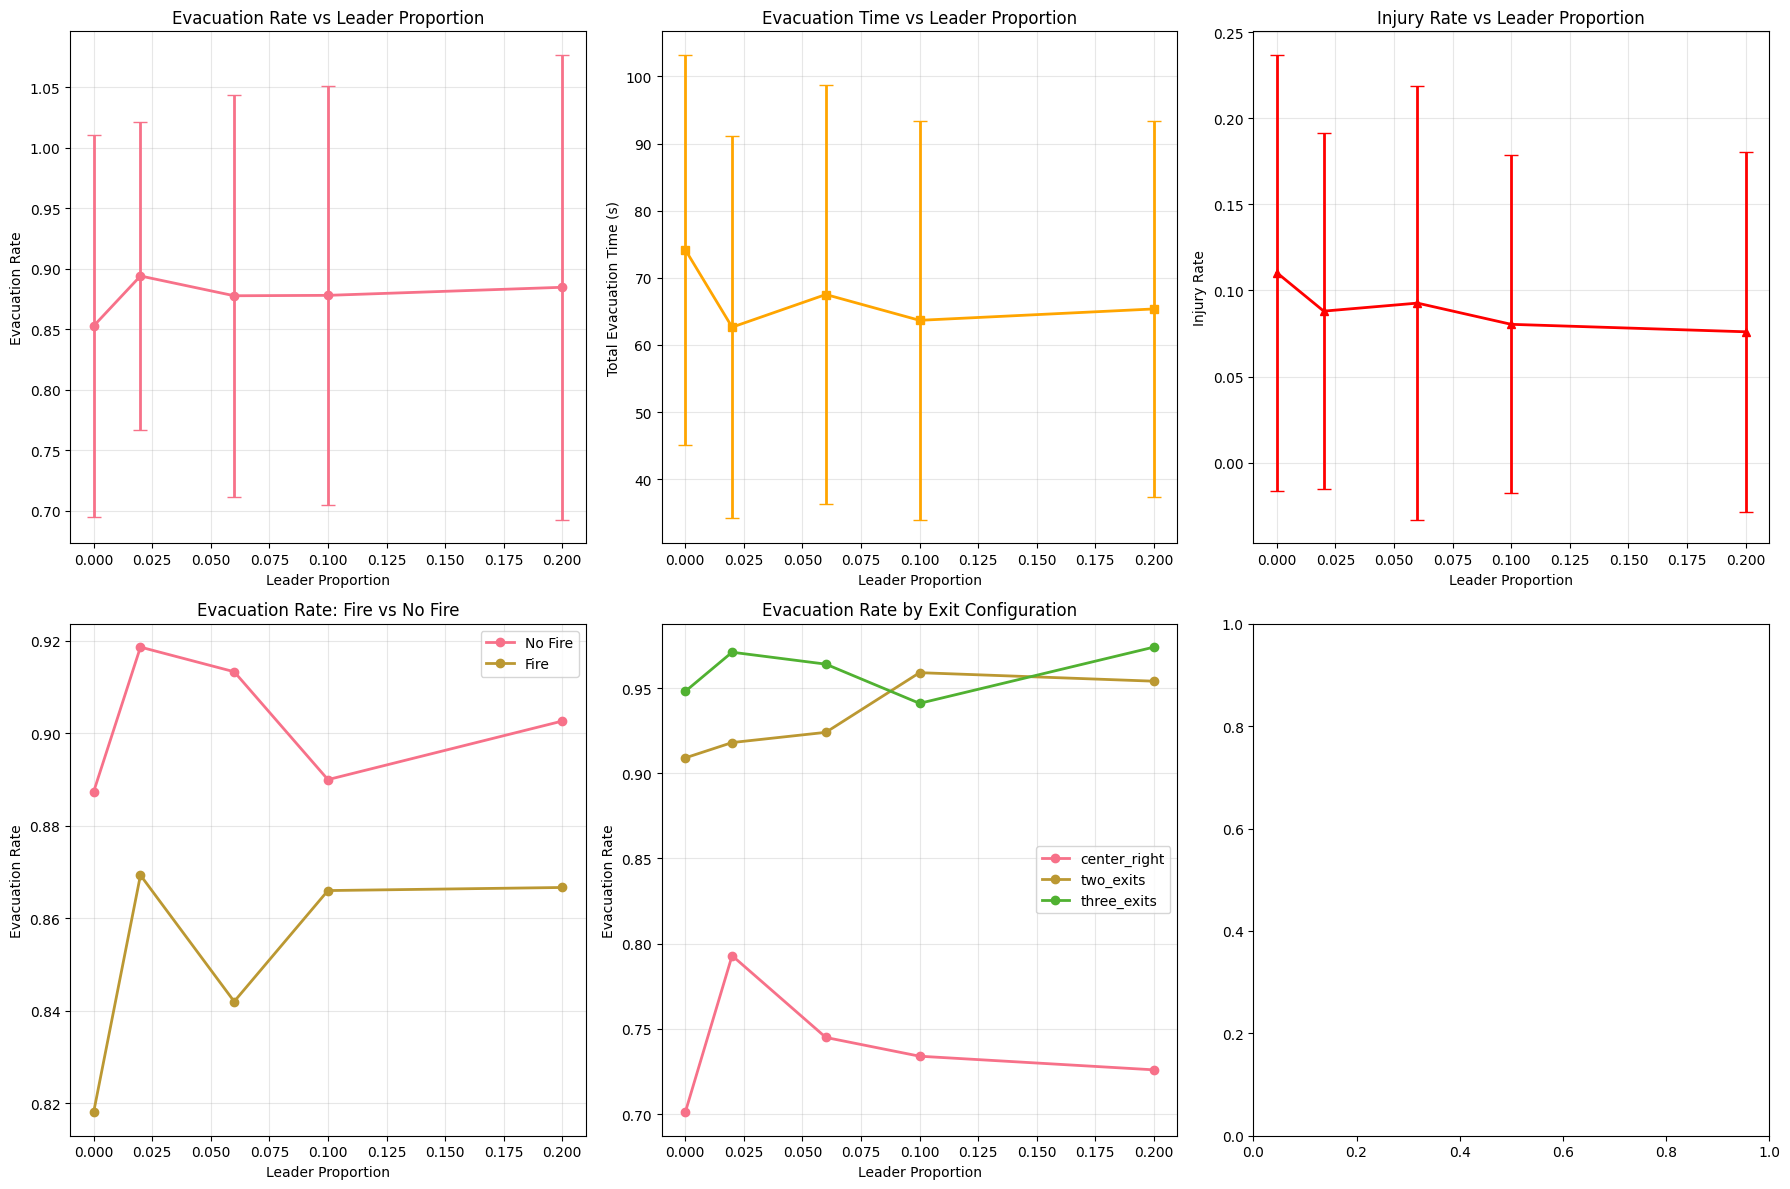

In [31]:
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Evacuation Rate by Leader Proportion
ax = axes[0, 0]
evacuation_data = detailed_df.groupby('leader_proportion')['evacuation_rate'].agg(['mean', 'std']).reset_index()
ax.errorbar(evacuation_data['leader_proportion'], evacuation_data['mean'], 
           yerr=evacuation_data['std'], marker='o', capsize=5, linewidth=2)
ax.set_xlabel('Leader Proportion')
ax.set_ylabel('Evacuation Rate')
ax.set_title('Evacuation Rate vs Leader Proportion')
ax.grid(True, alpha=0.3)

# 2. Total Time by Leader Proportion
ax = axes[0, 1]
time_data = detailed_df.groupby('leader_proportion')['total_time'].agg(['mean', 'std']).reset_index()
ax.errorbar(time_data['leader_proportion'], time_data['mean'], 
           yerr=time_data['std'], marker='s', capsize=5, linewidth=2, color='orange')
ax.set_xlabel('Leader Proportion')
ax.set_ylabel('Total Evacuation Time (s)')
ax.set_title('Evacuation Time vs Leader Proportion')
ax.grid(True, alpha=0.3)

# 3. Injury Rate by Leader Proportion
ax = axes[0, 2]
injury_data = detailed_df.groupby('leader_proportion')['injured_rate'].agg(['mean', 'std']).reset_index()
ax.errorbar(injury_data['leader_proportion'], injury_data['mean'], 
           yerr=injury_data['std'], marker='^', capsize=5, linewidth=2, color='red')
ax.set_xlabel('Leader Proportion')
ax.set_ylabel('Injury Rate')
ax.set_title('Injury Rate vs Leader Proportion')
ax.grid(True, alpha=0.3)

# 4. Leader Proportion effects by Fire Condition
ax = axes[1, 0]
for fire_condition in [False, True]:
    subset = detailed_df[detailed_df['fire_enabled'] == fire_condition]
    evac_by_leader = subset.groupby('leader_proportion')['evacuation_rate'].mean()
    label = 'Fire' if fire_condition else 'No Fire'
    ax.plot(evac_by_leader.index, evac_by_leader.values, marker='o', linewidth=2, label=label)
ax.set_xlabel('Leader Proportion')
ax.set_ylabel('Evacuation Rate')
ax.set_title('Evacuation Rate: Fire vs No Fire')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Leader Proportion effects by Exit Configuration
ax = axes[1, 1]
for exit_preset in detailed_df['exit_preset'].unique():
    subset = detailed_df[detailed_df['exit_preset'] == exit_preset]
    evac_by_leader = subset.groupby('leader_proportion')['evacuation_rate'].mean()
    ax.plot(evac_by_leader.index, evac_by_leader.values, marker='o', linewidth=2, label=exit_preset)
ax.set_xlabel('Leader Proportion')
ax.set_ylabel('Evacuation Rate')
ax.set_title('Evacuation Rate by Exit Configuration')
ax.legend()
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(exp_dir / "leader_proportion_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
def create_condition_heatmap(exp_dir, fire_enabled=True, exit_preset="two_exits", leader_proportion=0.20, 
                           save_plots=False, speed_threshold=0.01):
    """
    Create a position heatmap for a specific experimental condition, excluding injured agents.
    
    Args:
        exp_dir: Path to experiment directory
        fire_enabled: Fire condition (True/False)
        exit_preset: Exit configuration ("center_right", "two_exits", "three_exits")
        leader_proportion: Leader proportion (0.0 to 1.0)
        save_plots: Whether to save the plot
        speed_threshold: Minimum speed to include in heatmap (reduces "hot pixels" from stationary agents)
    
    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    
    # Load filtered data for this condition
    condition_results = load_experiment_results(
        exp_dir, 
        load_detailed_data=True, 
        parameter_filter={
            "fire_enabled": fire_enabled,
            "exit_preset": exit_preset, 
            "leader_proportion": leader_proportion
        }
    )
    
    if not condition_results['simulation_data']:
        print(f"No data found for condition: fire={fire_enabled}, exits={exit_preset}, leaders={leader_proportion}")
        return None, None
    
    print(f"Creating heatmap for: Fire={fire_enabled}, Exits={exit_preset}, Leaders={leader_proportion:.1%}")
    print(f"Found {len(condition_results['simulation_data'])} simulation runs")
    
    # Combine all agent data from all runs for this condition
    all_active_data = []
    
    for run_name, run_data in condition_results['simulation_data'].items():
        if 'agent_df' not in run_data:
            continue
            
        agent_df = run_data['agent_df']
        
        if agent_df.empty:
            continue
            
        # Convert to regular dataframe for easier manipulation
        df = agent_df.reset_index()
        
        # Find first injury step for each agent
        first_injury = df[df["injured"]].groupby("AgentID")["Step"].min()
        df["inj_step"] = df["AgentID"].map(first_injury)  # NaN if never injured
        
        # Keep only samples BEFORE injury (or all if never injured)
        active = df[(df["Step"] < df["inj_step"]) | df["inj_step"].isna()]
        
        # Filter out near-stationary agents to reduce noise
        active = active[active["Speed"] >= speed_threshold]
        
        # Add run identifier for debugging
        active["run_name"] = run_name
        
        all_active_data.append(active)
    
    if not all_active_data:
        print("No active agent data found!")
        return None, None
    
    # Combine all runs
    combined_df = pd.concat(all_active_data, ignore_index=True)
    
    print(f"Total active agent samples: {len(combined_df)}")
    print(f"Unique agents across runs: {combined_df['AgentID'].nunique()}")
    
    # Get room dimensions
    W, H = 15.0, 15.0
    
    # Extract positions
    all_x = combined_df["x"].to_numpy()
    all_y = combined_df["y"].to_numpy()
    
    # Create 2D histogram
    bins_x = int(np.clip(W * 3.0, 40, 150))
    bins_y = int(np.clip(H * 3.0, 40, 150))
    
    hist, xedges, yedges = np.histogram2d(
        all_x, all_y,
        bins=[bins_x, bins_y],
        range=[[0, W], [0, H]]
    )
    
    # Apply smoothing (I just copied this from data_collection.ipynb)
    def smooth_like_gaussian(img):
        """Tiny 3x3 Gaussian-ish blur."""
        k = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=float)
        k /= k.sum()
        pad = 1
        p = np.pad(img, pad_width=pad, mode="reflect")
        out = (
            k[0,0]*p[:-2, :-2] + k[0,1]*p[:-2, 1:-1] + k[0,2]*p[:-2, 2:] +
            k[1,0]*p[1:-1, :-2] + k[1,1]*p[1:-1, 1:-1] + k[1,2]*p[1:-1, 2:] +
            k[2,0]*p[2:, :-2] + k[2,1]*p[2:, 1:-1] + k[2,2]*p[2:, 2:]
        )
        return out
    
    smooth = smooth_like_gaussian(hist)
    
    # Percentile-based color scaling
    pos = smooth[smooth > 0]
    if pos.size:
        vmin = np.percentile(pos, 5)
        vmax = np.percentile(smooth, 99.5)
        if vmax <= vmin:
            vmax = vmin + 1e-6
    else:
        vmin, vmax = 0.0, 1.0
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Power normalization for better contrast
    norm = mcolors.PowerNorm(gamma=0.6, vmin=vmin, vmax=vmax)
    
    im = ax.imshow(
        smooth.T, origin='lower', aspect='equal',
        extent=[0, W, 0, H],
        cmap='inferno', norm=norm, alpha=0.9, zorder=1
    )
    
    # Add colorbar
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Agent visits (active only, smoothed)', fontsize=12)
    
    # Draw room layout (exits/walls)
    def draw_basic_layout(ax, exit_preset):
        """Draw basic room outline and exits based on preset."""
        # Room outline
        ax.plot([0, W, W, 0, 0], [0, 0, H, H, 0], 'k-', linewidth=3, alpha=0.9, zorder=3)
        
        # Exits based on preset
        exit_width = 2.0
        if exit_preset == "center_right":
            # Single exit on right wall
            y_center = H / 2
            ax.plot([W, W], [y_center - exit_width/2, y_center + exit_width/2], 
                   'g-', linewidth=6, alpha=0.9, zorder=4, label='Exit')
        elif exit_preset == "two_exits":
            # Right and left exits
            y_center = H / 2
            ax.plot([W, W], [y_center - exit_width/2, y_center + exit_width/2], 
                   'g-', linewidth=6, alpha=0.9, zorder=4)
            ax.plot([0, 0], [y_center - exit_width/2, y_center + exit_width/2], 
                   'g-', linewidth=6, alpha=0.9, zorder=4)
        elif exit_preset == "three_exits":
            # Right, left, and bottom exits
            y_center = H / 2
            x_center = W / 2
            ax.plot([W, W], [y_center - exit_width/2, y_center + exit_width/2], 
                   'g-', linewidth=6, alpha=0.9, zorder=4)
            ax.plot([0, 0], [y_center - exit_width/2, y_center + exit_width/2], 
                   'g-', linewidth=6, alpha=0.9, zorder=4)
            ax.plot([x_center - exit_width/2, x_center + exit_width/2], [0, 0], 
                   'g-', linewidth=6, alpha=0.9, zorder=4)
    
    draw_basic_layout(ax, exit_preset)
    
    # Formatting
    ax.set_xlim(-0.5, W + 0.5)
    ax.set_ylim(-0.5, H + 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('X [m]', fontsize=12)
    ax.set_ylabel('Y [m]', fontsize=12)
    
    # Title with condition info
    fire_str = "Fire" if fire_enabled else "No Fire"
    title = f'Agent Position Heatmap\n{fire_str}, {exit_preset.replace("_", " ").title()}, {leader_proportion:.0%} Leaders'
    ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    
    if save_plots:
        exp_dir = Path(exp_dir)
        filename = f"heatmap_fire_{fire_enabled}_exits_{exit_preset}_leaders_{leader_proportion:.2f}.png"
        plot_path = exp_dir / filename
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"Saved heatmap to: {plot_path}")
    
    plt.show()
    
    return fig, ax


Loaded experiment: Comprehensive extended agent experiment testing fire, multiple exits, and leadership effects on evacuation dynamics
Date: 2025-10-20T14:38:38.228766
Total runs: 300
Varied parameter(s): fire_enabled, exit_preset, num_exits, leader_proportion, num_leaders, seed, remaining_agents, overall_flow_rate, leaders_evacuated, leaders_remaining, leader_evacuation_rate, leader_flow_rate, injured_total, injured_rate, injured_fire, injured_smoke, injured_pressure, exit0_usage, exit1_usage, exit2_usage, exit_balance
Filtered to fire_enabled = True: 150 runs
Filtered to exit_preset = center_right: 50 runs
Filtered to leader_proportion = 0.0: 10 runs
Loading detailed simulation data...
Loaded simulation data for 10 runs
Creating heatmap for: Fire=True, Exits=center_right, Leaders=0.0%
Found 10 simulation runs
Total active agent samples: 132864
Unique agents across runs: 50


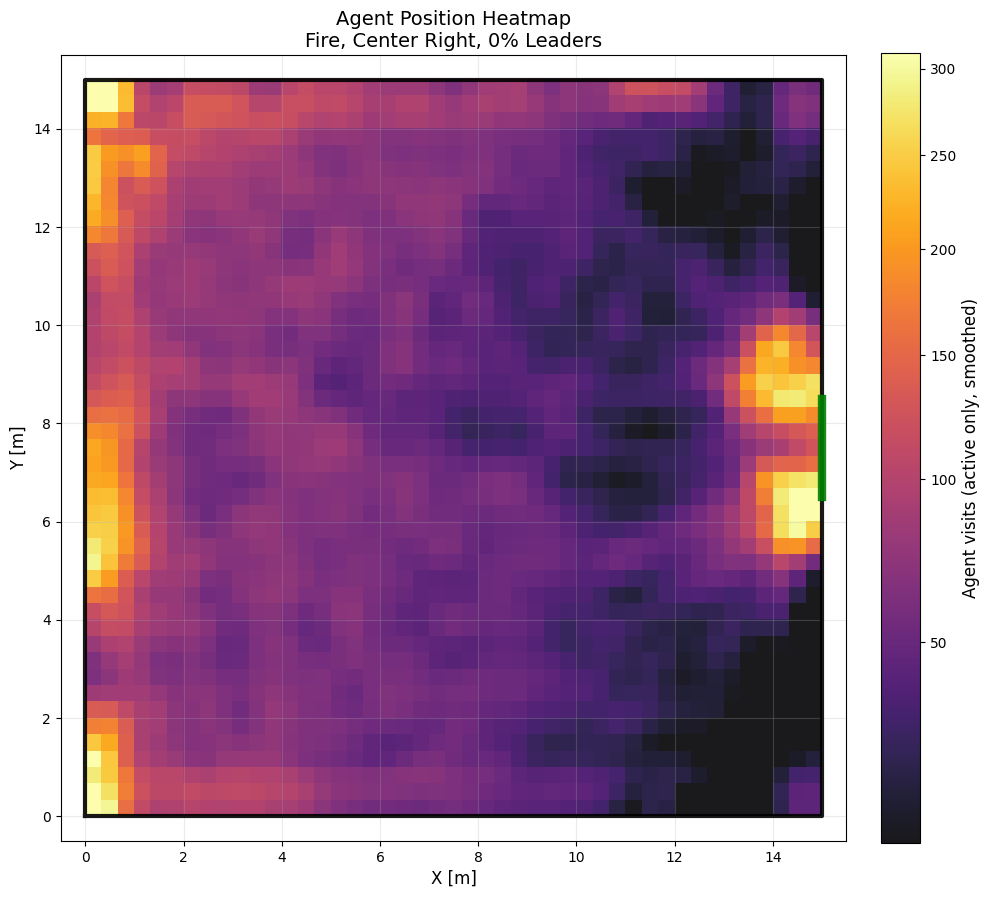

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Agent Position Heatmap\nFire, Center Right, 0% Leaders'}, xlabel='X [m]', ylabel='Y [m]'>)

In [18]:
# Load experiment directory
exp_dir = Path("experiments/extended_agents_full_20251020_143838")

# Generate heatmap for a condition :)
create_condition_heatmap(
    exp_dir, 
    fire_enabled=True, 
    exit_preset="center_right", 
    leader_proportion=0.00,
    save_plots=False
)